# Chapter 1

In [8]:
import networkx as nx
from matplotlib import pyplot as plt

In [2]:
nx.__version__

'3.6'

In [3]:
G = nx.Graph()

In [4]:
G.add_node('A')

In [5]:
G.add_nodes_from(['B','C'])

In [6]:
G.add_edge('A','B')

In [7]:
G.add_edges_from([('B','C'),('A','C')])

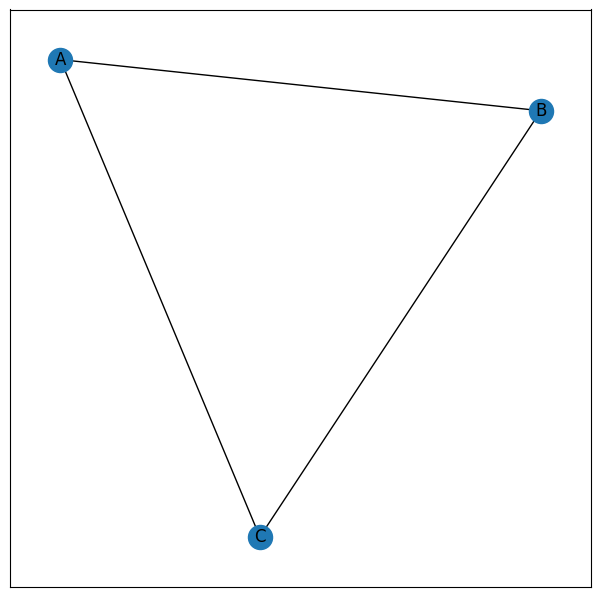

In [12]:
plt.figure(figsize = (7.5, 7.5))
nx.draw_networkx(G)
plt.show()

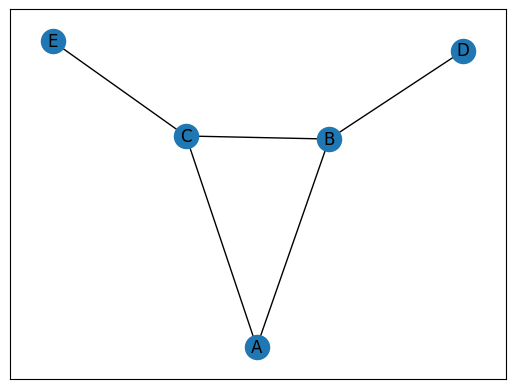

In [13]:
G.add_edges_from([('B','D'),('C','E')])
nx.draw_networkx(G)

# Chapter 2

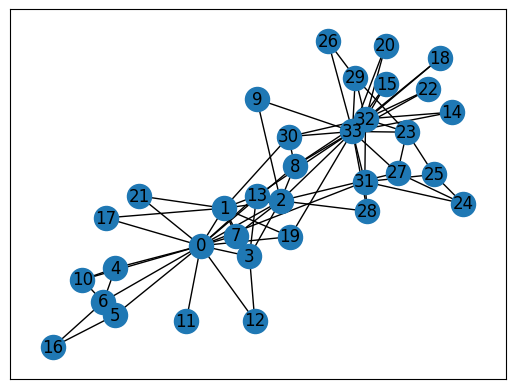

In [15]:
G = nx.karate_club_graph()
karate_pos = nx.spring_layout(G, k = 0.3)
nx.draw_networkx(G,karate_pos)

In [16]:
G.nodes

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33))

In [17]:
G.edges

EdgeView([(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 10), (0, 11), (0, 12), (0, 13), (0, 17), (0, 19), (0, 21), (0, 31), (1, 2), (1, 3), (1, 7), (1, 13), (1, 17), (1, 19), (1, 21), (1, 30), (2, 3), (2, 7), (2, 8), (2, 9), (2, 13), (2, 27), (2, 28), (2, 32), (3, 7), (3, 12), (3, 13), (4, 6), (4, 10), (5, 6), (5, 10), (5, 16), (6, 16), (8, 30), (8, 32), (8, 33), (9, 33), (13, 33), (14, 32), (14, 33), (15, 32), (15, 33), (18, 32), (18, 33), (19, 33), (20, 32), (20, 33), (22, 32), (22, 33), (23, 25), (23, 27), (23, 29), (23, 32), (23, 33), (24, 25), (24, 27), (24, 31), (25, 31), (26, 29), (26, 33), (27, 33), (28, 31), (28, 33), (29, 32), (29, 33), (30, 32), (30, 33), (31, 32), (31, 33), (32, 33)])

In [18]:
G.has_node(0)

True

In [20]:
list(G.neighbors(0))

[1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31]

In [21]:
(0,1) in G.edges()

True

In [22]:
members_club = [0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
                0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
                1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
                1, 1, 1, 1]

In [24]:
for i in G.nodes:
    G.nodes[i]['club'] = members_club[i]

In [25]:
G.add_node(11,club=0)

In [26]:
G.nodes[0]

{'club': 0}

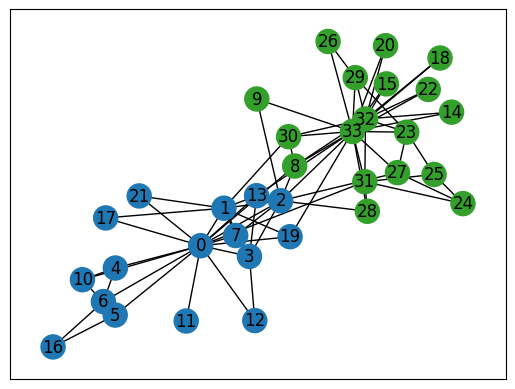

In [28]:
node_colors = [
    '#1f78b4' if G.nodes[v]['club'] == 0
    else '#33a02c' for v in G]
nx.draw_networkx(G,karate_pos,label = True, node_color = node_colors)

In [29]:
for v,w in G.edges:
    if G.nodes[v]['club'] == G.nodes[w]['club']:
        G.edges[v,w]['internal'] = True
    else:
        G.edges[v,w]['internal'] = False

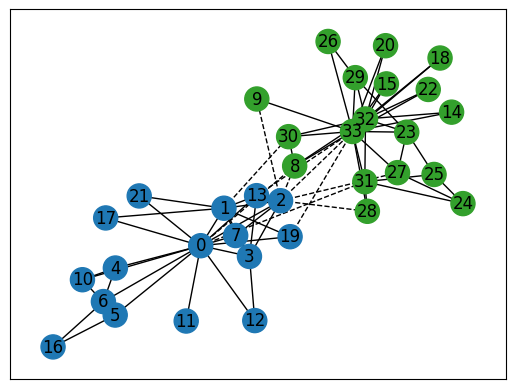

In [34]:
internal = [e for e in G.edges if G.edges[e]['internal']]
external = [e for e in G.edges if not G.edges[e]['internal']]
nx.draw_networkx_nodes(G, karate_pos, node_color = node_colors)
nx.draw_networkx_labels(G,karate_pos)
nx.draw_networkx_edges(G, karate_pos,edgelist = internal)
nx.draw_networkx_edges(G,karate_pos,edgelist=external,style='dashed')

In [35]:
def tie_strength(G,v,w):
    v_neighbors = set(G.neighbors(v))
    w_neighbors = set(G.neighbors(w))
    return 1+len(v_neighbors & w_neighbors)

In [41]:
for v,w in G.edges:
    G.edges[v,w]['weight'] = tie_strength(G,v,w)
    edge_weights = [G.edges[v,w]['weight'] for v,w in G.edges]

In [42]:
weighted_pos = nx.spring_layout(G, pos = karate_pos, k = 0.3, weight = 'weight')

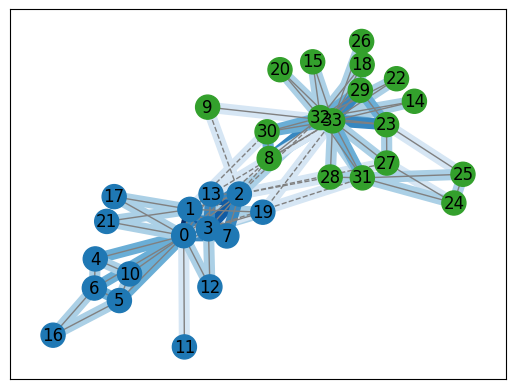

In [46]:
nx.draw_networkx(G,weighted_pos,width = 8, node_color = node_colors, edge_color = edge_weights, edge_cmap = plt.cm.Blues, edge_vmin = 0, edge_vmax = 6)
nx.draw_networkx_edges(G,weighted_pos, edgelist = internal,edge_color = 'gray')
nx.draw_networkx_edges(G,weighted_pos, edgelist = external,edge_color = 'gray',style = 'dashed')

# Chapter 4

In [48]:
import networkx as nx
from networkx.algorithms import bipartite
from networkx import NetworkXError

In [50]:
G = nx.karate_club_graph()
try:
    left,right = bipartite.sets(G)
    print("Left Nodes\n",left)
    print("\nRight Nodes\n",right)
except NetworkXError as e:
    print(e)

Graph is not bipartite.


In [51]:
G.edges

EdgeView([(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 10), (0, 11), (0, 12), (0, 13), (0, 17), (0, 19), (0, 21), (0, 31), (1, 2), (1, 3), (1, 7), (1, 13), (1, 17), (1, 19), (1, 21), (1, 30), (2, 3), (2, 7), (2, 8), (2, 9), (2, 13), (2, 27), (2, 28), (2, 32), (3, 7), (3, 12), (3, 13), (4, 6), (4, 10), (5, 6), (5, 10), (5, 16), (6, 16), (8, 30), (8, 32), (8, 33), (9, 33), (13, 33), (14, 32), (14, 33), (15, 32), (15, 33), (18, 32), (18, 33), (19, 33), (20, 32), (20, 33), (22, 32), (22, 33), (23, 25), (23, 27), (23, 29), (23, 32), (23, 33), (24, 25), (24, 27), (24, 31), (25, 31), (26, 29), (26, 33), (27, 33), (28, 31), (28, 33), (29, 32), (29, 33), (30, 32), (30, 33), (31, 32), (31, 33), (32, 33)])

In [54]:
B = nx.Graph()
B.add_edges_from([(v,(v,w)) for v,w in G.edges])
B.add_edges_from([(w,(v,w)) for v,w in G.edges])
try:
    left,right = bipartite.sets(B)
    print("Left Nodes\n",left)
    print("\nRight Nodes\n",right)
except NetworkXError as e:
    print(e)

Left Nodes
 {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33}

Right Nodes
 {(13, 33), (29, 32), (3, 13), (5, 10), (23, 25), (0, 5), (15, 32), (2, 32), (23, 27), (0, 7), (14, 33), (1, 17), (8, 32), (31, 33), (20, 33), (23, 29), (1, 19), (2, 27), (0, 2), (5, 16), (22, 32), (1, 3), (1, 21), (1, 30), (25, 31), (3, 12), (23, 33), (27, 33), (2, 13), (24, 25), (29, 33), (14, 32), (1, 7), (3, 7), (4, 6), (31, 32), (18, 32), (20, 32), (0, 11), (2, 8), (30, 33), (8, 33), (19, 33), (26, 29), (5, 6), (1, 2), (0, 4), (0, 13), (0, 31), (2, 28), (4, 10), (0, 6), (2, 3), (1, 13), (28, 31), (24, 27), (15, 33), (26, 33), (0, 8), (0, 17), (28, 33), (8, 30), (32, 33), (0, 1), (0, 10), (2, 7), (0, 19), (30, 32), (6, 16), (24, 31), (18, 33), (0, 3), (22, 33), (23, 32), (0, 12), (2, 9), (0, 21), (9, 33)}
